In [1]:
import os
import json
import shutil
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR    = Path("./emotion_data")
RAVDESS_DIR = BASE_DIR / "RAVDESS"
CREMAD_DIR  = BASE_DIR / "CREMA-D"
OUTPUT_DIR  = BASE_DIR / "processed_v2"     # separate from your old processed/

for folder in [BASE_DIR, RAVDESS_DIR, CREMAD_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders ready:")
for f in [RAVDESS_DIR, CREMAD_DIR, OUTPUT_DIR]:
    print(f"  {f.resolve()}")

Folders ready:
  D:\PROJECTS\Speech_to_Emotions\emotion_data\RAVDESS
  D:\PROJECTS\Speech_to_Emotions\emotion_data\CREMA-D
  D:\PROJECTS\Speech_to_Emotions\emotion_data\processed_v2


In [6]:
# ── Audio loading ────────────────────────────────────────────────
SR          = 16000      # 16 kHz — standard for speech; all files resampled to this
MAX_DURATION = 4.0       # seconds; clips/pads every file to exactly this length
MAX_SAMPLES  = int(SR * MAX_DURATION)   # = 64000 samples

# ── Mel-spectrogram parameters ───────────────────────────────────
N_FFT       = 1024       # FFT window size in samples (~64ms at 16kHz)
HOP_LENGTH  = 512        # step between windows (~32ms) — 50% overlap
N_MELS      = 64         # number of mel filterbank channels (frequency axis)
FMIN        = 50         # ignore frequencies below 50 Hz (not speech)
FMAX        = 8000       # ignore above 8000 Hz (Nyquist of 16kHz is 8kHz)

# ── Derived: time axis of the spectrogram ────────────────────────
# Number of frames = ceil(MAX_SAMPLES / HOP_LENGTH)
N_FRAMES    = 1 + MAX_SAMPLES // HOP_LENGTH   # = 125 frames
print(f"Each spectrogram will be  {N_MELS} mel bands × {N_FRAMES} time frames")
print(f"  -> shape fed to the model: (1, {N_MELS}, {N_FRAMES})   [C, H, W like an image]")
print(f"  -> time resolution: {HOP_LENGTH/SR*1000:.1f} ms per frame")
print(f"  -> freq resolution: {N_MELS} bands between {FMIN}–{FMAX} Hz")

Each spectrogram will be  64 mel bands × 126 time frames
  -> shape fed to the model: (1, 64, 126)   [C, H, W like an image]
  -> time resolution: 32.0 ms per frame
  -> freq resolution: 64 bands between 50–8000 Hz


In [7]:
RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '02': 'neutral',   # calm → mapped to neutral (CREMA-D has no calm)
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': None         # surprised → dropped (not in CREMA-D)
}

CREMAD_EMOTION_MAP = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

VALID_EMOTIONS  = sorted(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad'])
LABEL_TO_INT    = {e: i for i, e in enumerate(VALID_EMOTIONS)}
INT_TO_LABEL    = {i: e for e, i in LABEL_TO_INT.items()}
NUM_CLASSES     = len(VALID_EMOTIONS)

print("Emotion -> integer mapping:")
for e, i in LABEL_TO_INT.items():
    print(f"  {i}  {e}")

Emotion -> integer mapping:
  0  angry
  1  disgust
  2  fear
  3  happy
  4  neutral
  5  sad


In [8]:
def scan_wav(path):
    return list(Path(path).rglob("*.wav"))

def parse_ravdess(files):
    records = []
    for fp in files:
        code    = fp.stem.split('-')[2]
        emotion = RAVDESS_EMOTION_MAP.get(code)
        if emotion is None:
            continue
        records.append({'filepath': str(fp), 'emotion': emotion, 'source': 'ravdess'})
    return pd.DataFrame(records)

def parse_cremad(files):
    records = []
    for fp in files:
        parts = fp.stem.split('_')
        if len(parts) < 3:
            continue
        emotion = CREMAD_EMOTION_MAP.get(parts[2])
        if emotion is None:
            continue
        records.append({'filepath': str(fp), 'emotion': emotion, 'source': 'cremad'})
    return pd.DataFrame(records)

ravdess_files = scan_wav(RAVDESS_DIR)
cremad_files  = scan_wav(CREMAD_DIR)

df = pd.concat([parse_ravdess(ravdess_files),
                parse_cremad(cremad_files)], ignore_index=True)
df['label'] = df['emotion'].map(LABEL_TO_INT)

print(f"Total files : {len(df)}")
print(f"\nClass distribution:")
print(df['emotion'].value_counts().to_string())
print(f"\nSource split:")
print(df['source'].value_counts().to_string())

Total files : 9938

Class distribution:
emotion
neutral    1663
happy      1655
sad        1655
angry      1655
fear       1655
disgust    1655

Source split:
source
cremad     7442
ravdess    2496


In [9]:
def load_and_clean(filepath, sr=SR, max_samples=MAX_SAMPLES, top_db=35):
    """
    Load a wav file and return a fixed-length, cleaned waveform.

    Steps:
      1. Load at target SR (librosa resamples on the fly if needed)
      2. Trim leading/trailing silence using a 35dB threshold
      3. Peak-normalise to [-1, 1]
      4. Centre-crop or zero-pad to exactly MAX_SAMPLES (64000 samples = 4s)

    Returns: np.ndarray of shape (MAX_SAMPLES,), dtype float32
    """
    # Step 1: load + resample + mono
    y, _ = librosa.load(filepath, sr=sr, mono=True)

    # Step 2: trim silence
    # top_db=35 means: cut anything quieter than (peak - 35dB).
    # 30dB is aggressive (good for clean studio audio like RAVDESS).
    # 35dB is slightly gentler — better for CREMA-D which has more variety.
    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)
    if len(y_trimmed) < sr * 0.1:   # safety: if trim ate everything, revert
        y_trimmed = y

    # Step 3: peak normalise
    peak = np.max(np.abs(y_trimmed))
    if peak > 0:
        y_trimmed = y_trimmed / peak

    # Step 4: fixed length
    if len(y_trimmed) >= max_samples:
        # Centre-crop: keeps the emotionally rich middle of the utterance
        start = (len(y_trimmed) - max_samples) // 2
        y_out = y_trimmed[start : start + max_samples]
    else:
        # Zero-pad at the end
        y_out = np.pad(y_trimmed, (0, max_samples - len(y_trimmed)))

    return y_out.astype(np.float32)


# Quick sanity check
sample_path = df.iloc[0]['filepath']
y_sample    = load_and_clean(sample_path)
print(f"Output shape  : {y_sample.shape}  (should be ({MAX_SAMPLES},))")
print(f"Duration      : {len(y_sample)/SR:.2f}s")
print(f"Amplitude range: [{y_sample.min():.3f}, {y_sample.max():.3f}]")

Output shape  : (64000,)  (should be (64000,))
Duration      : 4.00s
Amplitude range: [-0.925, 1.000]


In [10]:
def extract_mel_spectrogram(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
                             n_mels=N_MELS, fmin=FMIN, fmax=FMAX,
                             n_frames=N_FRAMES):
    """
    Convert a waveform to a 2D log-mel spectrogram.

    Why mel-spectrogram instead of MFCC mean+std?
    ─────────────────────────────────────────────
    Your old pipeline:    waveform → MFCC (40, T) → mean over T → 40 numbers
                          Result: ALL temporal information is destroyed.

    This pipeline:        waveform → mel-spec (64, 125) → feed as 2D image
                          Result: full time-frequency structure is preserved.
                          The model sees HOW energy moves over time — that's
                          exactly what encodes emotion (rising pitch, sudden
                          silence, trembling voice, etc.)

    Steps:
      1. Compute mel-spectrogram: power in each of 64 frequency bands × 125 frames
      2. Convert to decibels (log scale): human hearing is logarithmic, and
         this compresses the huge dynamic range into a learnable range
      3. Normalise each spectrogram to [0, 1] using its own min/max
         (instance normalisation — makes the model robust to volume differences)
      4. Add a channel dimension → shape (1, 64, 125) so it looks like a
         single-channel (grayscale) image to a 2D CNN

    Returns: np.ndarray of shape (1, N_MELS, N_FRAMES), dtype float32
    """

    # Step 1: mel power spectrogram — shape: (n_mels, T)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax
    )

    # Step 2: convert to dB (log scale)
    # ref=np.max makes 0dB the loudest bin — relative loudness is preserved
    mel_db = librosa.power_to_db(mel, ref=np.max)   # shape: (n_mels, T)

    # Step 3: instance normalisation to [0, 1]
    # We do this per-file so the model learns from shape, not absolute loudness
    vmin, vmax = mel_db.min(), mel_db.max()
    if vmax - vmin > 1e-6:
        mel_norm = (mel_db - vmin) / (vmax - vmin)
    else:
        mel_norm = np.zeros_like(mel_db)   # silent file edge case

    # Step 4: ensure fixed time dimension
    # librosa may give T = N_FRAMES ± 1 due to rounding — clamp it
    if mel_norm.shape[1] >= n_frames:
        mel_norm = mel_norm[:, :n_frames]
    else:
        pad = n_frames - mel_norm.shape[1]
        mel_norm = np.pad(mel_norm, ((0, 0), (0, pad)))

    # Step 5: add channel dim → (1, n_mels, n_frames)
    return mel_norm[np.newaxis, :, :].astype(np.float32)


# Sanity check
spec = extract_mel_spectrogram(y_sample)
print(f"Spectrogram shape : {spec.shape}  (C, freq, time)")
print(f"Value range       : [{spec.min():.3f}, {spec.max():.3f}]")
print(f"Expected          : (1, {N_MELS}, {N_FRAMES})")

Spectrogram shape : (1, 64, 126)  (C, freq, time)
Value range       : [0.000, 1.000]
Expected          : (1, 64, 126)


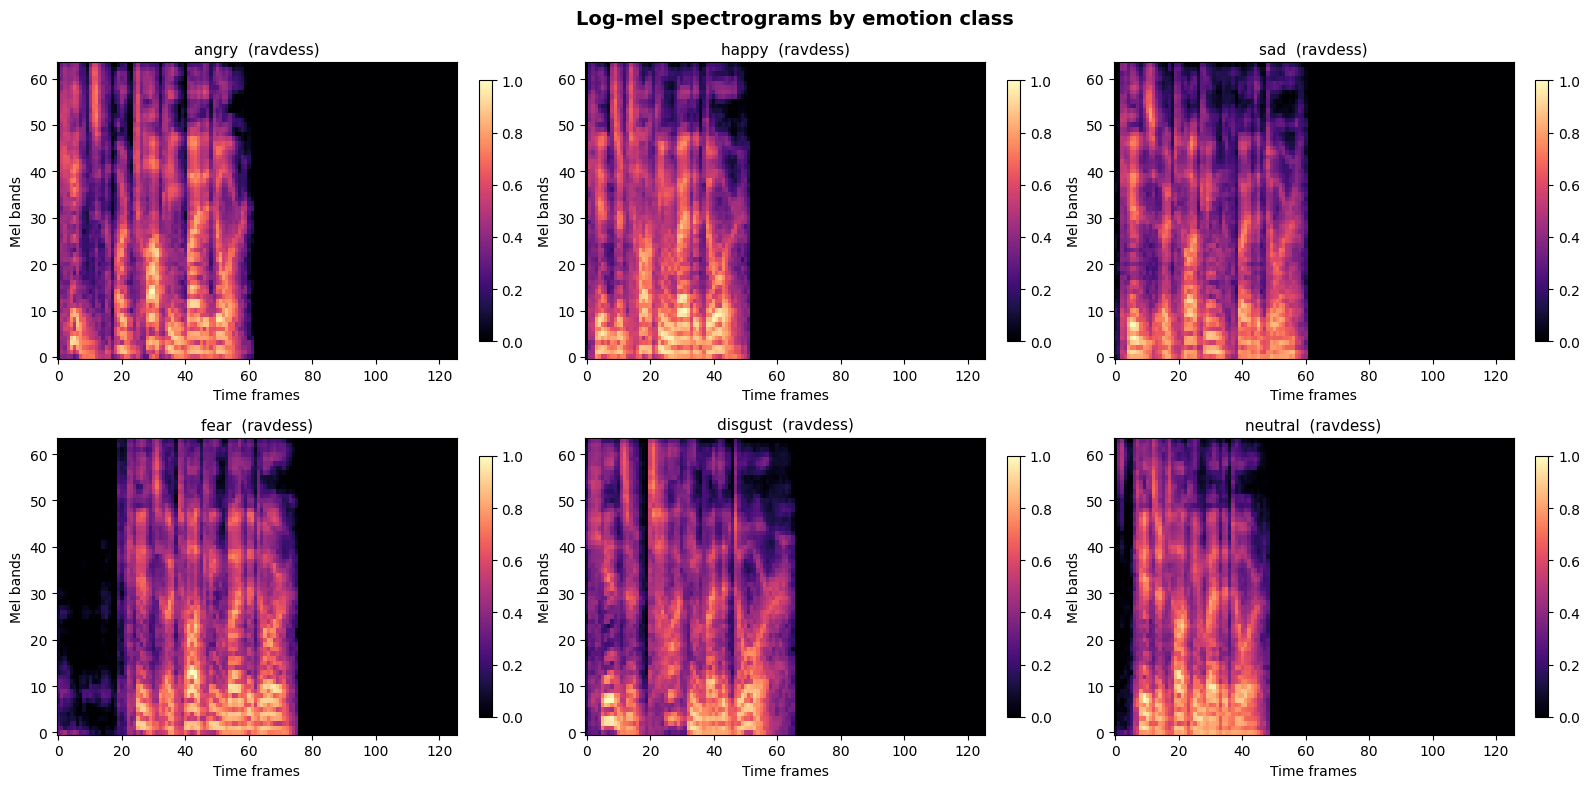

Saved - sample_spectrograms.png


In [12]:
emotions_to_show = ['angry', 'happy', 'sad', 'fear', 'disgust', 'neutral']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Log-mel spectrograms by emotion class", fontsize=14, fontweight='bold')

for ax, emotion in zip(axes.flatten(), emotions_to_show):
    row      = df[df['emotion'] == emotion].iloc[0]
    y_ex     = load_and_clean(row['filepath'])
    spec_ex  = extract_mel_spectrogram(y_ex)[0]   # drop channel dim for plotting

    img = ax.imshow(spec_ex, aspect='auto', origin='lower',
                    cmap='magma', vmin=0, vmax=1)
    ax.set_title(f"{emotion}  ({row['source']})", fontsize=11)
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bands")
    plt.colorbar(img, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig("sample_spectrograms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved - sample_spectrograms.png")

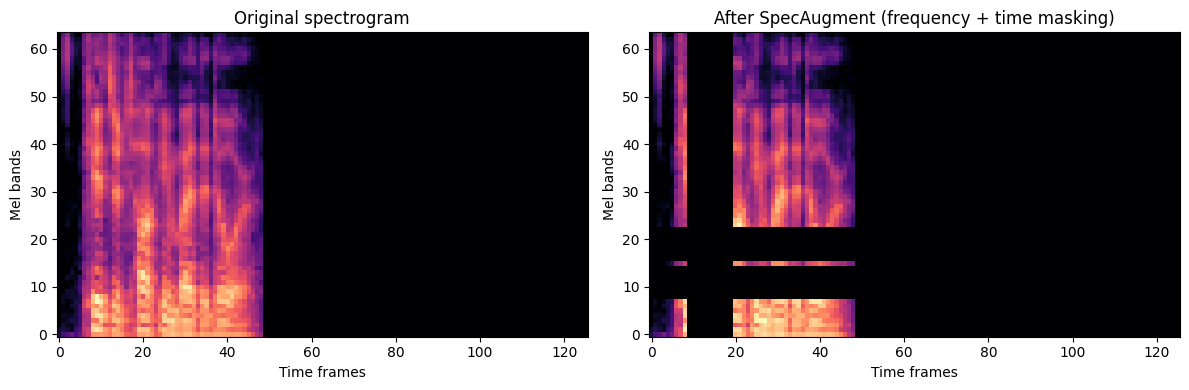

In [13]:
def spec_augment(spec, freq_mask_param=8, time_mask_param=20, num_freq_masks=2, num_time_masks=2):
    """
    SpecAugment: randomly zero out horizontal (frequency) and vertical (time) strips.

    Why do this in preprocessing rather than training?
    ──────────────────────────────────────────────────
    You can do it either place. Doing it here creates augmented copies saved to disk
    (so each file appears twice — once clean, once augmented). This doubles your
    dataset size without any runtime cost during training.

    What it does:
      - Frequency masking: zeros out `freq_mask_param` consecutive mel bands
        → forces the model to not rely on one narrow frequency region
      - Time masking: zeros out `time_mask_param` consecutive time frames
        → forces the model to handle partial information (mimics truncation, noise)

    This was introduced in the paper "SpecAugment: A Simple Data Augmentation Method
    for Automatic Speech Recognition" (Park et al., 2019) and is now standard in SER.

    spec: np.ndarray of shape (1, N_MELS, N_FRAMES)
    Returns: augmented copy, same shape
    """
    aug = spec.copy()   # never mutate the original
    _, n_mels, n_frames = aug.shape

    for _ in range(num_freq_masks):
        f      = np.random.randint(0, freq_mask_param + 1)
        f_start = np.random.randint(0, max(1, n_mels - f))
        aug[0, f_start : f_start + f, :] = 0.0

    for _ in range(num_time_masks):
        t       = np.random.randint(0, time_mask_param + 1)
        t_start = np.random.randint(0, max(1, n_frames - t))
        aug[0, :, t_start : t_start + t] = 0.0

    return aug


# Visualise the effect of SpecAugment
y_aug    = load_and_clean(df.iloc[0]['filepath'])
spec_raw = extract_mel_spectrogram(y_aug)
spec_aug = spec_augment(spec_raw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(spec_raw[0], aspect='auto', origin='lower', cmap='magma')
ax1.set_title("Original spectrogram")
ax2.imshow(spec_aug[0], aspect='auto', origin='lower', cmap='magma')
ax2.set_title("After SpecAugment (frequency + time masking)")
for ax in [ax1, ax2]:
    ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bands")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "specaugment_example.png", dpi=150)
plt.show()

In [14]:
AUGMENT_TRAINING = True   # set False if you want to skip augmentation for now

records      = []
failed_files = []

print(f"Processing {len(df)} files...")
print(f"SpecAugment on originals: {AUGMENT_TRAINING}\n")

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
    try:
        # Load and clean waveform
        y = load_and_clean(row['filepath'])

        # Extract clean spectrogram
        spec_clean = extract_mel_spectrogram(y)

        records.append({
            'filepath' : row['filepath'],
            'emotion'  : row['emotion'],
            'label'    : row['label'],
            'source'   : row['source'],
            'augmented': False,
            'spec'     : spec_clean
        })

        # If augmentation is on, also add a SpecAugment copy
        if AUGMENT_TRAINING:
            spec_aug = spec_augment(spec_clean)
            records.append({
                'filepath' : row['filepath'],
                'emotion'  : row['emotion'],
                'label'    : row['label'],
                'source'   : row['source'],
                'augmented': True,
                'spec'     : spec_aug
            })

    except Exception as e:
        failed_files.append({'filepath': row['filepath'], 'error': str(e)})

print(f"\n✓ Processed  : {len([r for r in records if not r['augmented']])} original files")
print(f"✓ Augmented  : {len([r for r in records if r['augmented']])} augmented copies")
print(f"✓ Total      : {len(records)} samples")
print(f"✗ Failed     : {len(failed_files)}")
if failed_files:
    for f in failed_files[:5]:
        print(f"  {Path(f['filepath']).name} → {f['error']}")

Processing 9938 files...
SpecAugment on originals: True



Extracting: 100%|██████████| 9938/9938 [02:20<00:00, 70.67it/s]


✓ Processed  : 9938 original files
✓ Augmented  : 9938 augmented copies
✓ Total      : 19876 samples
✗ Failed     : 0


In [15]:
# Separate clean vs augmented BEFORE saving
# Rule: train can see augmented; val and test NEVER see augmented copies
clean_records = [r for r in records if not r['augmented']]
aug_records   = [r for r in records if     r['augmented']]

# Stack into numpy arrays
X_clean  = np.stack([r['spec'] for r in clean_records]).astype(np.float32)
y_clean  = np.array([r['label'] for r in clean_records], dtype=np.int64)

X_aug    = np.stack([r['spec'] for r in aug_records]).astype(np.float32) if aug_records else None
y_aug    = np.array([r['label'] for r in aug_records], dtype=np.int64) if aug_records else None

print(f"X_clean shape : {X_clean.shape}   (N, C, H, W) = (samples, 1, {N_MELS}, {N_FRAMES})")
print(f"y_clean shape : {y_clean.shape}")
if X_aug is not None:
    print(f"X_aug shape   : {X_aug.shape}")
    print(f"y_aug shape   : {y_aug.shape}")

# Save
np.save(OUTPUT_DIR / "X_clean.npy",   X_clean)
np.save(OUTPUT_DIR / "y_clean.npy",   y_clean)
if X_aug is not None:
    np.save(OUTPUT_DIR / "X_aug.npy", X_aug)
    np.save(OUTPUT_DIR / "y_aug.npy", y_aug)

# Save metadata CSV (no spec column)
meta_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'spec'} for r in records
])
meta_df.to_csv(OUTPUT_DIR / "metadata.csv", index=False)

# Save label map
with open(OUTPUT_DIR / "label_map.json", "w") as f:
    json.dump({'label_to_int': LABEL_TO_INT,
               'int_to_label': INT_TO_LABEL}, f, indent=2)

print(f"\nSaved to {OUTPUT_DIR.resolve()}:")
for p in sorted(OUTPUT_DIR.iterdir()):
    mb = p.stat().st_size / (1024**2)
    print(f"  {p.name:<30} {mb:.1f} MB")

X_clean shape : (9938, 1, 64, 126)   (N, C, H, W) = (samples, 1, 64, 126)
y_clean shape : (9938,)
X_aug shape   : (9938, 1, 64, 126)
y_aug shape   : (9938,)

Saved to D:\PROJECTS\Speech_to_Emotions\emotion_data\processed_v2:
  label_map.json                 0.0 MB
  metadata.csv                   1.4 MB
  X_aug.npy                      305.7 MB
  X_clean.npy                    305.7 MB
  y_aug.npy                      0.1 MB
  y_clean.npy                    0.1 MB


In [16]:
# Reload and verify
X = np.load(OUTPUT_DIR / "X_clean.npy")
y = np.load(OUTPUT_DIR / "y_clean.npy")

print("="*50)
print("  Final dataset summary")
print("="*50)
print(f"  X shape   : {X.shape}   ← (N, 1, {N_MELS}, {N_FRAMES})")
print(f"  y shape   : {y.shape}")
print(f"  X dtype   : {X.dtype}")
print(f"  X range   : [{X.min():.4f}, {X.max():.4f}]  (should be 0–1)")
print(f"  NaN in X  : {np.isnan(X).any()}")
print(f"  Inf in X  : {np.isinf(X).any()}")
print()

print("  Class distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    bar = '█' * (c // 50)
    print(f"    {INT_TO_LABEL[u]:<10} label={u}  {c:>5}  {bar}")
print("="*50)

  Final dataset summary
  X shape   : (9938, 1, 64, 126)   ← (N, 1, 64, 126)
  y shape   : (9938,)
  X dtype   : float32
  X range   : [0.0000, 1.0000]  (should be 0–1)
  NaN in X  : False
  Inf in X  : False

  Class distribution:
    angry      label=0   1655  █████████████████████████████████
    disgust    label=1   1655  █████████████████████████████████
    fear       label=2   1655  █████████████████████████████████
    happy      label=3   1655  █████████████████████████████████
    neutral    label=4   1663  █████████████████████████████████
    sad        label=5   1655  █████████████████████████████████
